In [75]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Optional for aesthetics
from scipy.stats import linregress
import datetime

data_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/'

In [42]:
# Read CSV file into a DataFrame
df = pd.read_csv(data_path + 'S_seaice_extent_daily_v3.0_2.csv'
                ,  sep=';')

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']].astype(str).agg('-'.join, axis=1))
df.set_index('Date', inplace=True)
ds = xr.Dataset({'Extent': df['Extent']})

ds['day_of_year'] = ds['Date'].dt.dayofyear
ds['Year'] = ds['Date'].dt.year
ds = ds.set_coords('day_of_year')
ds = ds.set_coords('Year')
ds

<xarray.Dataset>
Dimensions:      (Date: 14919)
Coordinates:
  * Date         (Date) datetime64[ns] 1978-10-26 1978-10-28 ... 2024-03-07
    day_of_year  (Date) int64 299 301 303 305 307 309 311 ... 62 63 64 65 66 67
    Year         (Date) int64 1978 1978 1978 1978 1978 ... 2024 2024 2024 2024
Data variables:
    Extent       (Date) float64 17.62 17.8 17.67 17.53 ... 2.681 2.753 2.809

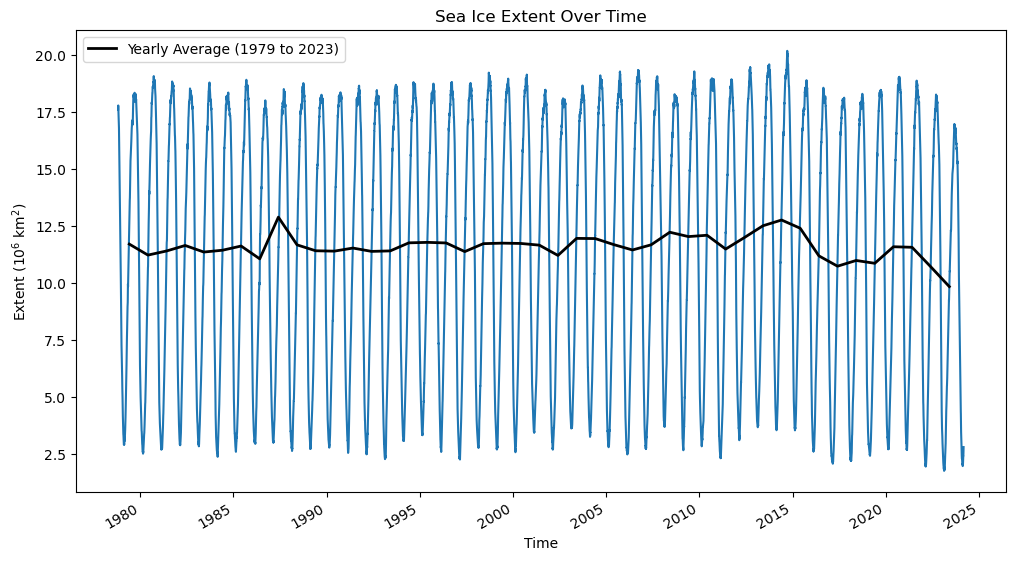

In [98]:
# Plot Extent over time
plt.figure(figsize=(12, 6))
ds['Extent'].plot()
plt.title('Sea Ice Extent Over Time')
plt.xlabel('Time')
plt.ylabel('Extent (10$^6$ km$^2$)')

#Add yearly average
yearly_average = ds['Extent'].groupby('Year').mean()
start_year = yearly_average.Year.min().data
end_year = yearly_average.Year.max().data
date_list = [datetime.date(year, 6, 1) for year in range(start_year, end_year + 1)]
date_strings = [date.strftime('%Y-%m-%d') for date in date_list]
plt.plot(pd.to_datetime(date_strings[1:-1]), yearly_average[1:-1], color='black', 
         label='Yearly Average ('+str(start_year+1)+' to '+str(end_year-1)+')', linewidth=2)
plt.legend()
plt.savefig('Fig_SIE_yearly_average.png')


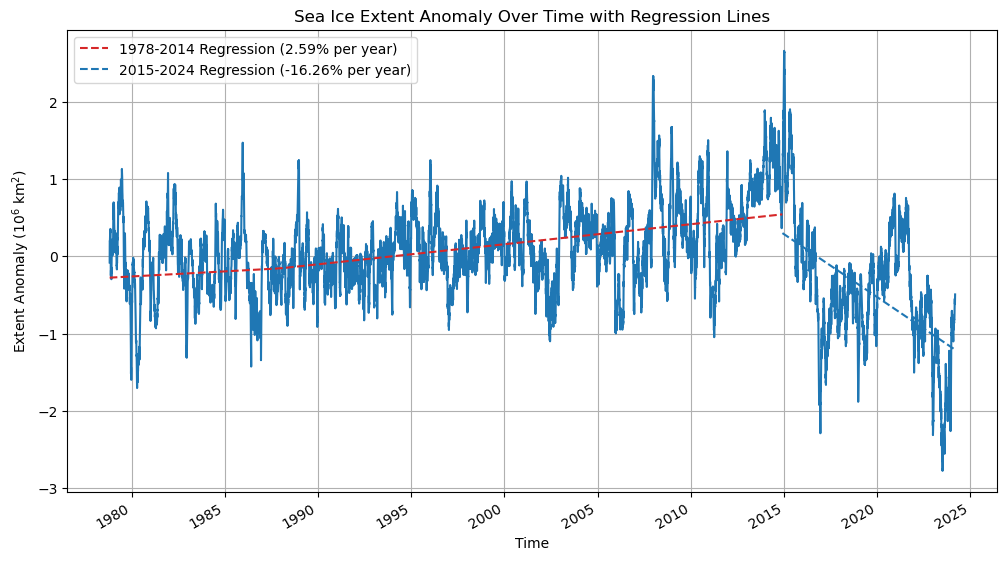

In [126]:
# Calculate the anomaly
doy = ds['Extent'].groupby('day_of_year')
anomaly = doy - doy.mean()

# Plot Extent over time Anomaly
plt.figure(figsize=(12, 6))
anomaly.plot()

# Calculate regression lines
x_values = np.arange(len(anomaly))
ind = df.index.get_loc('2014-12-01')
regress_1978_2014 = linregress(x_values[:ind], anomaly.values[:ind])
regress_2014_2024 = linregress(x_values[ind:], anomaly.values[ind:])

# Convert slope to percentage change per year
slope_percentage_1978_2014 = regress_1978_2014.slope * 100 * 365
slope_percentage_2014_2024 = regress_2014_2024.slope * 100 * 365

# Plot regression lines with slope in percentage per year
plt.plot(ds['Date'][:ind], regress_1978_2014.slope * x_values[:ind] + regress_1978_2014.intercept, 
         label=f'1978-2014 Regression ({slope_percentage_1978_2014:.2f}% per year)', 
         color='tab:red', linestyle='--')
plt.plot(ds['Date'][ind:], regress_2014_2024.slope * x_values[ind:] + regress_2014_2024.intercept, 
         label=f'2015-2024 Regression ({slope_percentage_2014_2024:.2f}% per year)', 
         color='tab:blue', linestyle='--')

# Set labels and title
plt.title('Sea Ice Extent Anomaly Over Time with Regression Lines')
plt.xlabel('Time')
plt.ylabel('Extent Anomaly (10$^6$ km$^2$)')
plt.legend()
plt.grid()

# Save or show the plot
plt.savefig('Fig_SIE_anomaly_with_regression_percentage.png')
plt.show()


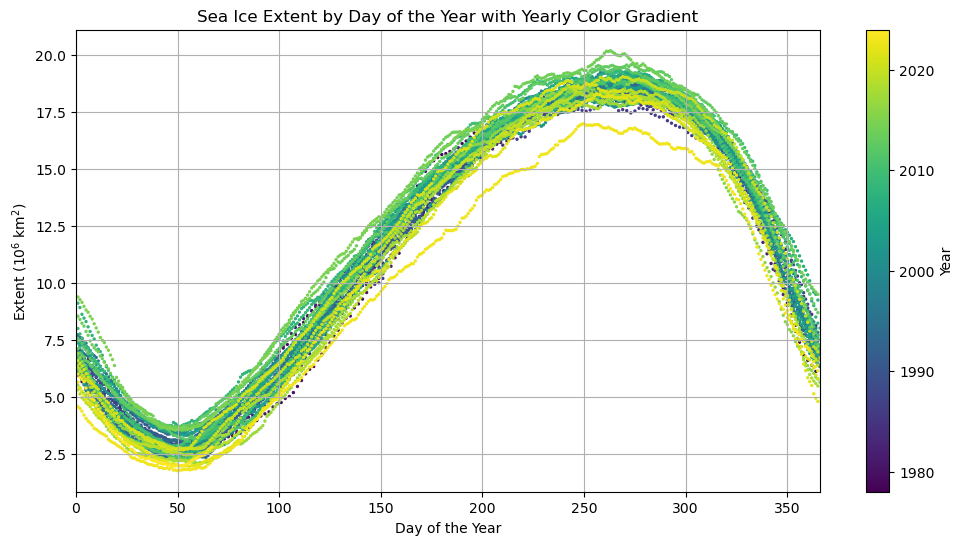

In [93]:
cmap = sns.color_palette("viridis", as_cmap=True)

# Plot Extent in terms of day of the year with color gradient by year
plt.figure(figsize=(12, 6))
sc = plt.scatter(ds['day_of_year'], ds['Extent'], c=ds['Year'], cmap=cmap, s=2)
plt.colorbar(sc, label='Year')
plt.grid()
plt.xlim([0, 366])
plt.title('Sea Ice Extent by Day of the Year with Yearly Color Gradient')
plt.xlabel('Day of the Year')
plt.ylabel('Extent ($10^6$ km$^2$)')
plt.savefig('Fig_SIE_with_colorbar.png')
plt.show()